In [211]:
# --- Core imports
import os
import sys
import copy
import logging
import warnings
import time
from os.path import join
from pathlib import Path

# --- Numerical / data
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

# --- Power systems / geospatial
import pypsa
import atlite
from shapely.geometry import Point, box
from shapely.ops import unary_union
import shapely

# Optional plotting (only used in helper plot function)
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Optional: powerplantmatching (picks up config but we keep local CSV as source of truth)
try:
    import powerplantmatching as pm
    HAVE_PPM = True
except Exception:
    HAVE_PPM = False

# --- Silence noisy warnings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)
warnings.filterwarnings('ignore')


# --- Logging
parent_dir = Path(os.getcwd()).parents[0]          # project/
LOG_FILE = join(parent_dir, "logs.log")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.FileHandler(LOG_FILE, encoding="utf-8"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)

# --- Project paths helper
sys.path.append(str(parent_dir))
from src.paths import all_dirs  # must exist in your repo
dirs = all_dirs()

# --- Add PyPSA-Earth scripts to PATH (assumes repo layout: <project>/../pypsa-earth/scripts)
scripts_path = os.path.join(parent_dir.parents[0], "pypsa-earth", "scripts")
assert os.path.isdir(scripts_path), f"Path not found: {scripts_path}"
sys.path.append(scripts_path)

####### THIS IS TEMPORAL, needs to 
YEAR = 2050
SNAPPING_H = 1
LEN_OPT = 24*30
DEMAND_SCALING = "base" #  ["base", "high"]
assert DEMAND_SCALING in ["base", "high"], "DEMAND_SCALING must be 'base' or 'high'"
demand_columm = "Tendencial" if DEMAND_SCALING == "base" else "Expansion"
SCALING_FACTOR = 1.0  # scaling factor for demand and generation profiles


scaling_data = pd.read_csv(
    os.path.join(
        dirs["data/processed/demand"],
        "demand_prognosis_2022_2050.csv"
    ), index_col=0)

base_demand = scaling_data.at[2022,"Tendencial"]
future_demand_total = scaling_data.at[YEAR, demand_columm]
SCALING_FACTOR = future_demand_total / base_demand
print(f"Scaling factor for demand and generation profiles for year {YEAR}: {SCALING_FACTOR:.3f}")
####### END TEMPORAL

Scaling factor for demand and generation profiles for year 2050: 2.429


In [212]:
# Load the 2022 network
network_2022_path = join(
    dirs["data/processed/networks"], "ec_network_2022.nc"
)
network = pypsa.Network(network_2022_path)
logger.info(f"Loaded network for Ecuador from {network_2022_path}")
network.set_snapshots(pd.date_range(f"{YEAR}-01-01", f"{YEAR}-12-31 23:00", freq="H"))






2026-01-14 15:57:37: Imported network ec_network_2022.nc has buses, lines, transformers
2026-01-14 15:57:37: Loaded network for Ecuador from c:\Repositories\Repos\pypsa-earth-project\EcuadorElectricGrid\data\processed\networks\ec_network_2022.nc


In [213]:
import pandas as pd

def find_lv_only_subnetworks(n, hv_threshold_kv=137.0):
    n.determine_network_topology()

    bus_sn = n.buses.sub_network

    stats = n.buses.assign(sub_network=bus_sn).groupby("sub_network").agg(
        n_buses=("v_nom", "size"),
        vmin=("v_nom", "min"),
        vmax=("v_nom", "max"),
    )
    stats["has_hv"] = stats["vmax"] >= hv_threshold_kv

    lv_only_sns = stats.index[~stats["has_hv"]]
    lv_only_buses = n.buses.index[bus_sn.isin(lv_only_sns)]

    return lv_only_sns, lv_only_buses, stats, bus_sn


lv_sns, lv_buses, sn_stats, bus_sn = find_lv_only_subnetworks(network, hv_threshold_kv=137.0)

# --- 1) Flat list of bus IDs (strings) ---
lv_bus_list = lv_buses.astype(str).tolist()
print(f"LV-only buses ({len(lv_bus_list)}):")
print(lv_bus_list)

# --- 2) Grouped: subnetwork_id -> list of bus IDs ---
lv_buses_by_sn = (
    pd.Series(lv_buses.astype(str), index=lv_buses)
      .groupby(bus_sn.loc[lv_buses])
      .apply(list)
      .sort_index()
)

print("\nLV-only buses by sub_network:")
for sn_id, buses in lv_buses_by_sn.items():
    print(f"  sub_network {sn_id}: {buses}")

# --- 3) Optional: save for later ---
# CSV with two columns: sub_network, bus
out_csv = "lv_only_buses.csv"
pd.DataFrame({
    "sub_network": bus_sn.loc[lv_buses].values,
    "bus": lv_buses.astype(str).values,
}).sort_values(["sub_network", "bus"]).to_csv(out_csv, index=False)

# JSON dict: {sub_network: [bus, bus, ...]}
out_json = "lv_only_buses_by_subnetwork.json"
lv_buses_by_sn.to_dict()
pd.Series(lv_buses_by_sn.to_dict()).to_json(out_json, indent=2)

print(f"\nSaved: {out_csv} and {out_json}")


LV-only buses (43):
['116', '127', '133', '148', '149', '150', '156', '169', '170', '171', '174', '178', '182', '183', '189', '191', '192', '199', '207', '208', '209', '211', '213', '214', '242', '243', '244', '246', '254', '255', '259', '274', '275', '276', '283', '284', '286', '293', '295', '299', '308', '309', '310']

LV-only buses by sub_network:
  sub_network 1: ['116', '259']
  sub_network 10: ['178', '286']
  sub_network 11: ['182', '183']
  sub_network 13: ['189', '293']
  sub_network 14: ['191', '192']
  sub_network 15: ['199', '295']
  sub_network 16: ['208', '209']
  sub_network 17: ['211', '299']
  sub_network 18: ['213', '214', '310']
  sub_network 19: ['246', '309']
  sub_network 2: ['127', '242', '243', '244', '308']
  sub_network 20: ['254', '255']
  sub_network 3: ['133', '156']
  sub_network 4: ['148', '274']
  sub_network 5: ['149', '275']
  sub_network 6: ['150', '276']
  sub_network 8: ['169', '170', '171', '207', '283']
  sub_network 9: ['174', '284']

Saved: lv_o

In [214]:
len(lv_bus_list)


43

In [215]:
def prune_network_min_voltage(n, v_threshold_kv=137.0):
    """
    Keep only buses with v_nom >= v_threshold_kv and remove any components
    (transformers, lines, links, loads, generators, stores, storage_units, shunts)
    that reference removed buses.
    """
    import numpy as np
    n = n.copy()

    # 1) Decide which buses to keep
    buses_orig = n.buses.index.astype(str)
    keep_buses = n.buses.index[n.buses["v_nom"] >= float(v_threshold_kv)].astype(str)
    keep_set   = set(keep_buses)
    drop_set   = set(buses_orig) - keep_set

    print(f"Keeping {len(keep_buses)}/{len(buses_orig)} buses (v_nom >= {v_threshold_kv} kV).")
    if drop_set:
        print(f"Dropping {len(drop_set)} buses due to voltage threshold.")

    # helper to drop rows by bus column name if bus not in keep_set
    def _drop_by_bus(df, bus_col):
        if df.empty or bus_col not in df.columns:
            return df.index[:0]
        mask = ~df[bus_col].astype(str).isin(keep_set)
        return df.index[mask]

    # 2) Collect components to drop because they reference removed buses
    to_drop = {
        "Load":          _drop_by_bus(n.loads, "bus"),
        "Generator":     _drop_by_bus(n.generators, "bus"),
        "Store":         _drop_by_bus(getattr(n, "stores"), "bus") if hasattr(n, "stores") else [],
        "StorageUnit":   _drop_by_bus(n.storage_units, "bus") if hasattr(n, "storage_units") else [],
        "ShuntImpedance": _drop_by_bus(getattr(n, "shunt_impedances"), "bus") if hasattr(n, "shunt_impedances") else [],
        "Line":          n.lines.index[
                            ~n.lines["bus0"].astype(str).isin(keep_set) |
                            ~n.lines["bus1"].astype(str).isin(keep_set)
                        ],
        "Transformer":   n.transformers.index[
                            ~n.transformers["bus0"].astype(str).isin(keep_set) |
                            ~n.transformers["bus1"].astype(str).isin(keep_set)
                        ],
        "Link":          n.links.index[
                            ~n.links["bus0"].astype(str).isin(keep_set) |
                            ~n.links["bus1"].astype(str).isin(keep_set)
                        ] if len(n.links) else []
    }

    # 3) Remove them from the network using PyPSA's API
    for comp, idx in to_drop.items():
        idx = list(idx)
        if not idx:
            continue
        for name in idx:
            try:
                n.remove(comp, name)
            except Exception as e:
                # be robust if component table missing etc.
                pass
        print(f"Removed {len(idx):4d} {comp}(s) referencing dropped buses.")

    # 4) Finally, restrict the buses table itself to the kept set
    n.buses = n.buses.loc[keep_buses]

    # Optional: clean orphaned carriers/sub-networks etc. if needed

    return n

# ---- use it ----
network = prune_network_min_voltage(network, v_threshold_kv=137.0)



Keeping 110/295 buses (v_nom >= 137.0 kV).
Dropping 185 buses due to voltage threshold.
Removed  141 Line(s) referencing dropped buses.
Removed   43 Transformer(s) referencing dropped buses.


In [216]:
# 2) Loads: add p_set time series
# 2) Loads: add p_set time series with nearest-bus remapping for unknown buses
path_loads = dirs["data/processed/demand"]
load_profile_name = "demand_profiles_2022.csv"
load_profile_file = join(path_loads, load_profile_name)
logger.info(f"Loading load profile: {load_profile_file}")
load_profile = pd.read_csv(load_profile_file, index_col=0, parse_dates=True)

# total_load_before_removal = load_profile.sum().sum()
# logger.info(f"Total load before removing LV buses: {total_load_before_removal} kW")



#here, remove the load profiles for buses that are in lv_bus_list
load_profile = load_profile.drop(columns=lv_bus_list, errors='ignore')


total_load_after_removal = load_profile.sum().sum()
#logger.info(f"Total load after removing LV buses: {total_load_before_removal} kW")

scaling_factor = SCALING_FACTOR*1/1000  # from kW to MW
#rescaling also for the removal of LV buses
#re_scaling_factor = total_load_before_removal / total_load_after_removal
load_profile = load_profile*scaling_factor
logger.info(f"Scaled all load profile values by factor {scaling_factor}")


try:

    # --- Ensure column names are strings
    load_cols = [str(c) for c in load_profile.columns]
    load_profile.columns = load_cols

    # --- Existing buses in the active network
    buses_now = network.buses.copy()
    buses_now.index = buses_now.index.astype(str)
    existing_buses = set(buses_now.index)

    # --- Find missing bus labels
    missing = [c for c in load_cols if c not in existing_buses]
    if missing:
        logger.warning(f"{len(missing)} load buses not found; reassigning to nearest existing bus.")
    else:
        logger.info("All load buses found in current network.")

    # --- Build KDTree on current network buses
    from scipy.spatial import cKDTree as KDTree
    use_lonlat = {"lon", "lat"}.issubset(buses_now.columns)
    if use_lonlat:
        coords_now = buses_now.loc[:, ["lon", "lat"]].to_numpy(dtype=float)
    else:
        coords_now = buses_now.loc[:, ["x", "y"]].to_numpy(dtype=float)
    kdt_now = KDTree(coords_now)

    network_dir_fb = dirs["data/raw/networks"]
    network_files_fb = ["base"]
    fallback_networks = {}
    for nf in network_files_fb:
        f = join(network_dir_fb, f"{nf}.nc")
        if os.path.isfile(f):
            fallback_networks[nf] = pypsa.Network(f)
    # --- Helper: try to get coordinates for a missing bus from any fallback network
    print("Searching in fallback networks:")
    print(fallback_networks)
    def find_bus_coords_in_fallbacks(bus_name: str):

        for nf, net_fb in fallback_networks.items():
            try:
                df = net_fb.buses.copy()
                df.index = df.index.astype(str)
                if bus_name in df.index:
                    if {"lon", "lat"}.issubset(df.columns):
                        #print("Found in: ", nf)
                        return ("lonlat",
                                float(df.loc[bus_name, "lon"]),
                                float(df.loc[bus_name, "lat"]))
                    elif {"x", "y"}.issubset(df.columns):
                        #print("Found in: ", nf)
                        return ("xy",
                                float(df.loc[bus_name, "x"]),
                                float(df.loc[bus_name, "y"]))
                
            except Exception:
                
                pass
        return None

    # --- Build a bus assignment vector aligned with load columns
    bus_assignments = []
    remap_report = []

    for c in load_cols:
        if c in existing_buses:
            bus_assignments.append(c)  # unchanged
            continue

        # Try to recover coordinates for this bus label from other networks
        info = find_bus_coords_in_fallbacks(c)
        if info is not None:
            kind, bx, by = info
            # Query KDTree (always built for current network in the coordinate type we have)
            if use_lonlat and kind == "lonlat":
                q = np.array([[bx, by]])
            elif (not use_lonlat) and kind == "xy":
                q = np.array([[bx, by]])
            else:
                # Coordinate kind mismatch; cannot reliably transform → use crude nearest by lon/lat if both exist,
                # else by x/y. If mismatch, try whichever exists in current network.
                if use_lonlat and kind == "xy":
                    # We only have xy for missing, but KDTree is lon/lat → fallback to closest by index 0
                    # (transparent about this in logs)
                    remap_report.append((c, None, None, "coord_kind_mismatch"))
                    # Pick the closest *by index* fallback: use network's geometric center
                    # (KDTree needs a point; we’ll use median lon/lat)
                    q = np.nanmedian(coords_now, axis=0)[None, :]
                elif (not use_lonlat) and kind == "lonlat":
                    remap_report.append((c, None, None, "coord_kind_mismatch"))
                    q = np.nanmedian(coords_now, axis=0)[None, :]
                else:
                    q = np.nanmedian(coords_now, axis=0)[None, :]
            idx = int(kdt_now.query(q)[1][0])
            nearest_bus = buses_now.index[idx]
            bus_assignments.append(nearest_bus)
            remap_report.append((c, bx, by, f"mapped_to:{nearest_bus}"))
        else:
            # No coordinates found anywhere → attach to globally nearest by network centroid
            idx = int(kdt_now.query(np.nanmedian(coords_now, axis=0)[None, :])[1][0])
            nearest_bus = buses_now.index[idx]
            bus_assignments.append(nearest_bus)
            remap_report.append((c, None, None, f"mapped_to:{nearest_bus};reason:no_coords"))

    if remap_report:
        logger.info("Load bus remapping performed (missing → nearest existing):")
        for r in remap_report:
            logger.info(f"  load '{r[0]}' → {r[3]} (src_coords: {r[1]}, {r[2]})")

    # --- Finally add Loads with reassigned buses
    network.madd("Load", load_cols, bus=bus_assignments, p_set=load_profile)

    # Peak (GW)
    peak_load = round(network.loads_t.p_set.T.sum().max() / 1000, 1)
    logger.info(f"Peak load in p_set time series: {peak_load} GW")

except Exception as e:
    logger.warning(f"Could not attach loads: {e}")



2026-01-14 15:57:37: Loading load profile: c:\Repositories\Repos\pypsa-earth-project\EcuadorElectricGrid\data\processed\demand\demand_profiles_2022.csv
2026-01-14 15:57:37: Scaled all load profile values by factor 0.0024289972624963584
2026-01-14 15:57:37: 160 load buses not found; reassigning to nearest existing bus.
2026-01-14 15:57:38: Imported network base.nc has buses, lines, transformers
Searching in fallback networks:
{'base': PyPSA Network 'PyPSA-Earth'
Components:
 - Bus: 313
 - Line: 247
 - Transformer: 62
Snapshots: 8760}
2026-01-14 15:57:38: Load bus remapping performed (missing → nearest existing):
2026-01-14 15:57:38:   load '0' → mapped_to:1 (src_coords: -78.6904, -1.6524)
2026-01-14 15:57:38:   load '2' → mapped_to:3 (src_coords: -80.8895, -2.2304)
2026-01-14 15:57:38:   load '6' → mapped_to:7 (src_coords: -78.5372, -0.3652)
2026-01-14 15:57:38:   load '9' → mapped_to:10 (src_coords: -78.6094, -0.7952)
2026-01-14 15:57:38:   load '13' → mapped_to:14 (src_coords: -78.603

In [217]:
# ======================================================================
#                      3) Power plants table (EXCEL)
# ======================================================================
from pathlib import Path
import os
import numpy as np
import pandas as pd

ppl_xlsx = join(dirs["data/processed/generation"], "cleaned_generation_2022.xlsx")
assert os.path.isfile(ppl_xlsx), f"Power plants XLSX not found: {ppl_xlsx}"

# 1) Read Excel
raw = pd.read_excel(ppl_xlsx, sheet_name=0, engine="openpyxl")
raw.columns = [str(c).strip() for c in raw.columns]

# 2) Build a "legacy/PPM-friendly" table from your new structure
#    (so the rest of your code can stay basically unchanged)
required = {
    "Empresa", "Central", "Sistema", "Tipo_de_Central", "Subtipo_de_Central",
    "Potencia_Nominal_MW", "Latitud", "Longitud"
}
missing = sorted(required - set(raw.columns))
if missing:
    raise ValueError(f"Missing required columns in XLSX: {missing}")

def _norm_system(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    # your file uses SNI; previous CSV used S.N.I.
    if s in {"sni", "s.n.i.", "s.n.i"}:
        return "S.N.I."
    if s in {"no_incorporado", "no incorporado", "no-incorporado"}:
        return "No_Incorporado"
    return str(x).strip()

# Prefer Central_id if present; else build a stable name
if "Central_id" in raw.columns:
    name_series = raw["Central_id"].astype(str).str.strip()
else:
    name_series = (raw["Central"].astype(str).str.strip())# + "-" + raw["Central"].astype(str).str.strip())

# Capacity in MW (your column is Potencia_Nominal_MW)
capacity_mw = pd.to_numeric(raw["Potencia_Nominal_MW"], errors="coerce")

ppl_raw = pd.DataFrame(
    {
        # Columns similar to the old CSV schema (enough for pm + your later logic)
        "Name": name_series,
        "Fueltype": raw["Tipo_de_Central"],
        "Technology": raw["Subtipo_de_Central"].fillna(raw.get("Technology", np.nan)),
        "Set": raw["Sistema"].apply(_norm_system),
        "Country": "Ecuador",
        "Capacity": capacity_mw,          # MW
        "Efficiency": np.nan,
        "Duration": np.nan,
        "Volume_Mm3": np.nan,
        "DamHeight_m": np.nan,
        "StorageCapacity_MWh": np.nan,
        # DateIn is not present in your XLSX; set a safe default so filtering works.
        # If you later add a commissioning-year column, replace this assignment.
        "DateIn": int(YEAR),
        "DateRetrofit": np.nan,
        "DateOut": np.nan,
        "lat": pd.to_numeric(raw["Latitud"], errors="coerce"),
        "lon": pd.to_numeric(raw["Longitud"], errors="coerce"),
        "EIC": np.nan,
        "projectID": raw.get("Central_id", np.nan),
    }
)

# mimic your previous "index_col=0" behavior
ppl_raw = ppl_raw.set_index("Name", drop=False)

# --- OPTIONAL (recommended): normalize using powerplantmatching
ppl = ppl_raw.copy()
try:
    import powerplantmatching as pm

    ppmatching = os.path.join(
        Path(os.getcwd()).parents[1], "pypsa-earth", "configs", "powerplantmatching_config.yaml"
    )
    config = pm.get_config(ppmatching)
    config["target_countries"] = ["EC"]  # Ecuador

    # fill missing commissioning years (you already set DateIn=YEAR, so this is safe)
    ppl_f = ppl.powerplant.fill_missing_commissioning_years()
    # convert to PyPSA-compatible naming conventions
    ppl_p = ppl_f.powerplant.to_pypsa_names()

    # Drop all-empty columns that may be introduced by upstream merges
    ppl = ppl_p.dropna(axis=1, how="all")

    logger.info("Applied powerplantmatching normalization (fill years + to_pypsa_names).")
except Exception as e:
    logger.warning(f"powerplantmatching step skipped (using raw XLSX-adapted table): {e}")
    ppl = ppl_raw.copy()

# ----------------------------------------------------------------------
# From here onward, your existing normalization/filtering can remain,
# with just a couple of safety fallbacks (p_nom/carrier/component).
# ----------------------------------------------------------------------

def _normalize_text(s):
    import unicodedata, re
    if pd.isna(s):
        return None
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"\s+", " ", s)
    return s

# Ensure p_nom exists (PyPSA usually uses MW; keep MW consistently)
if "p_nom" not in ppl.columns:
    if "Capacity" in ppl.columns:
        ppl["p_nom"] = pd.to_numeric(ppl["Capacity"], errors="coerce").fillna(0.0)
    else:
        logger.warning("Neither 'p_nom' nor 'Capacity' found; setting p_nom=0.0")
        ppl["p_nom"] = 0.0
else:
    ppl["p_nom"] = pd.to_numeric(ppl["p_nom"], errors="coerce").fillna(0.0)

# Ensure carrier exists (if pm skipped)
if "carrier" not in ppl.columns:
    # best-effort: use Fueltype if present
    if "Fueltype" in ppl.columns:
        ppl["carrier"] = ppl["Fueltype"]
    else:
        ppl["carrier"] = np.nan

# map carriers (ES->EN)
ppl["carrier_norm"] = ppl["carrier"].apply(_normalize_text)
carrier_map_es2en = {
    "hidraulica": "hydro",
    "hidroelectrico": "hydro",
    "termica": "oil",
    "termoelectrico": "oil",
    "biomasa": "biomass",
    "fotovoltaica": "solar",
    "solar": "solar",
    "eolica": "onwind",
    "eolico": "onwind",
    "biogas": "biomass",
    "ernc": "onwind",
    "nuclear": "nuclear",
    "geotermica": "geothermal",
    "carbón": "coal",
    "carbon": "coal",
    "lignito": "lignite",
    "gas natural": "natural gas",
    "gas": "natural gas",
    "phs": "PHS",
    "pasada": "ror",
    "embalse": "hydro",
    "offshore": "offwind-ac",
    "offshore_dc": "offwind-dc",
}
ppl["carrier"] = ppl["carrier_norm"].map(carrier_map_es2en).fillna(ppl["carrier_norm"])

# ---- Filter: SNI, by year and minimum size (MW)
FILTERING_POWER = 0.0
DATE_IN = int(YEAR)

# Some tables may have 'component' (from pm), others only 'Set'
component_col = "component" if "component" in ppl.columns else ("Set" if "Set" in ppl.columns else None)

if component_col and {"DateIn", "p_nom"}.issubset(ppl.columns):
    ppl_connected = ppl[ppl[component_col] == "S.N.I."]
    ppl_connected_current = ppl_connected[ppl_connected["DateIn"] <= DATE_IN]
    ppl_filtered = ppl_connected_current[ppl_connected_current["p_nom"] >= FILTERING_POWER].copy()
else:
    logger.warning("Required columns for filtering missing; skipping filter.")
    ppl_filtered = ppl.copy()

# ---- Totals (MW)
def safe_sum(series):
    try:
        return float(series.sum())
    except Exception:
        return np.nan

total_capacity = safe_sum(ppl.get("p_nom", pd.Series(dtype=float)))
total_connected = safe_sum(ppl_connected.get("p_nom", pd.Series(dtype=float))) if "ppl_connected" in locals() else np.nan
total_connected_current = safe_sum(ppl_connected_current.get("p_nom", pd.Series(dtype=float))) if "ppl_connected_current" in locals() else np.nan
total_filtered = safe_sum(ppl_filtered.get("p_nom", pd.Series(dtype=float)))

logger.info(
    "Capacities [MW]\n"
    f"  total:                   {total_capacity:,.2f}\n"
    f"  connected (SNI):         {total_connected:,.2f}\n"
    f"  connected <= {DATE_IN}:  {total_connected_current:,.2f}\n"
    f"  filtered (>= {FILTERING_POWER:.2f} MW): {total_filtered:,.2f}"
)


2026-01-14 15:57:38: Applied powerplantmatching normalization (fill years + to_pypsa_names).
2026-01-14 15:57:38: Capacities [MW]
  total:                   7,493.65
  connected (SNI):         7,493.65
  connected <= 2050:  7,493.65
  filtered (>= 0.00 MW): 7,493.65


In [218]:
# 4) Attach filtered plants to nearest LV substation

from scipy.spatial import cKDTree as KDTree

def attach_to_nearest_lv_bus(net: pypsa.Network, plants_df: pd.DataFrame) -> pd.DataFrame:
    """Attach plants to nearest bus among those marked substation_lv."""
    if "substation_lv" not in net.buses.columns:
        raise ValueError("network.buses must contain a boolean 'substation_lv' column")

    if not {"lon", "lat"}.issubset(plants_df.columns):
        raise ValueError("plants_df must contain 'lon' and 'lat' columns")

    sub_idx = net.buses.query("substation_lv").index
    if len(sub_idx) == 0:
        raise ValueError("No LV substations found (substation_lv == True).")

    kdt = KDTree(net.buses.loc[sub_idx, ["x", "y"]].values)

    # Query nearest bus for each plant lon/lat -> need plant x/y; network.buses stores x,y in projected units.
    # If network.buses has lon/lat columns, prefer those:
    if {"lon", "lat"}.issubset(net.buses.columns):
        # Build a lon/lat->index KDTree as fallback using lon/lat and not x/y
        # But your buses KDTree above already used x/y; keep consistent by translating plants to bus CRS when available.
        pass

    # Best-effort: assume bus x/y ~ proj coords corresponding to lon/lat mapping already in network
    # If network carries bus lon/lat, we project plants into the same 'x/y' via a crude nearest in lon/lat space:
    # For robustness (and speed), use lon/lat KDTree when bus lon/lat exist:
    use_lonlat_tree = {"lon", "lat"}.issubset(net.buses.columns)
    if use_lonlat_tree:
        kdt_ll = KDTree(net.buses.loc[sub_idx, ["lon", "lat"]].values)
        tree_i = kdt_ll.query(plants_df.loc[:, ["lon", "lat"]].values)[1]
    else:
        # fallback to x/y KDTree (will work if plant lon/lat columns are actually x/y already)
        tree_i = kdt.query(plants_df.loc[:, ["lon", "lat"]].values)[1]

    attached = plants_df.copy()
    attached["bus"] = sub_idx.append(pd.Index([np.nan]))[tree_i].astype(str)
    missing = ~attached["bus"].isin(net.buses.index)
    if missing.any():
        logger.warning(f"Found {missing.sum()} plants with non-existing bus assignments.")
    return attached

try:
    ppl_attached = attach_to_nearest_lv_bus(network, ppl_filtered)
except Exception as e:
    logger.warning(f"Could not attach plants to LV buses: {e}")
    ppl_attached = ppl_filtered.copy()
    ppl_attached["bus"] = np.nan


In [219]:
ppl_attached.to_csv("ppl_attached.csv")


In [220]:
# 5) Safely add generators to the network

def add_generators_safe(net: pypsa.Network, pp_df: pd.DataFrame):
    needed = ["bus", "carrier", "p_nom"]
    if not set(needed).issubset(pp_df.columns):
        raise ValueError(f"Missing columns in plant df. Need at least: {needed}")

    # PyPSA expects per-generator rows. We’ll use index as names.
    added = 0
    for i in pp_df.index:
        row = pp_df.loc[[i]]
        try:
            
            net.madd("Generator",
                     row.index,
                     bus=row["bus"].values,
                     carrier=row["carrier"].values,
                     p_nom=row["p_nom"].values)
            added += 1
        except Exception as e:
            logger.warning(f"  ⚠ could not add {i}: {e}")
    logger.info(f"Generators added: {added}")

try:
    add_generators_safe(network, ppl_attached)
except Exception as e:
    logger.warning(f"Adding generators failed: {e}")

network.generators = network.generators[network.generators["carrier"].isna()==False]  



2026-01-14 15:57:39: Generators added: 137


In [221]:
# gens_clean from previous step
gens_clean = (
    network.generators[
        ~network.generators["carrier"].str.contains("shedding", case=False, na=False)
    ]
    .sort_values("p_nom")
)

# Add the bus voltage (v_nom) to gens_clean
gens_clean = gens_clean.join(
    network.buses["v_nom"].rename("bus_v_nom"),
    on="bus"
)

gens_clean[["bus", "carrier", "p_nom", "bus_v_nom"]]



,bus,carrier,p_nom,bus_v_nom
Generator,,,,
Tilivi,11,hydro,0.10,138.0
Sillunchi_I,111,hydro,0.10,138.0
Enersol,273,solar,0.50,138.0
Fabrica_Imbabura,288,hydro,0.79,138.0
Hidrocarolina,288,hydro,0.92,138.0
...,...,...,...,...
San_Francisco,110,hydro,230.00,230.0
Minas_San_Francisco,159,hydro,270.00,230.0
Sopladora,52,hydro,487.00,138.0


In [222]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import unicodedata

re_dict = {}

def _norm_province_name(name: str) -> str:
    if not isinstance(name, str):
        name = str(name)
    # strip accents
    name = unicodedata.normalize("NFKD", name)
    name = "".join(ch for ch in name if not unicodedata.combining(ch))
    # lower, trim, unify separators
    name = name.strip().lower()
    name = name.replace(" ", "_").replace("-", "_")
    # collapse multiple underscores
    while "__" in name:
        name = name.replace("__", "_")
    return name

# --- Select renewable generators ---
mask = ppl_attached["carrier"].isin(["solar", "onwind"])
ren_gens = ppl_attached[mask]

# --- Load centroids CSV ---
centroids_csv_path = os.path.join(dirs["data/raw/gadm"], "EC_centroids.csv")
centroids = pd.read_csv(centroids_csv_path)

for col in ["province", "longitude", "latitude"]:
    if col not in centroids.columns:
        raise ValueError(f"Centroid CSV must contain column '{col}'")

centroids["province_norm"] = centroids["province"].map(_norm_province_name)
cent_lon = centroids["longitude"].astype(float).values
cent_lat = centroids["latitude"].astype(float).values
cent_name_norm = centroids["province_norm"].values

# --- Load cutouts ONCE ---
solar_ds = xr.open_dataset(os.path.join(dirs["data/raw/cutouts"], "solar.nc"))
wind_ds  = xr.open_dataset(os.path.join(dirs["data/raw/cutouts"], "onwind.nc"))

# a) provinces from solar_ds.bus.data
provinces_raw = pd.Index(solar_ds.bus.data)
provinces_norm = provinces_raw.to_series().map(_norm_province_name)

# map normalized -> original name/index
norm_to_raw = dict(zip(provinces_norm.values, provinces_raw.values))

# b) profile DataFrames (time x province_raw)
solar_profiles = solar_ds["profile"].to_pandas()
solar_profiles.columns = provinces_raw

wind_profiles = wind_ds["profile"].to_pandas()
wind_profiles.columns = provinces_raw

# align to snapshots
YEAR_BASE= 2013
temporal_snapshots = pd.date_range(f"{YEAR_BASE}-01-01", f"{YEAR_BASE}-12-31 23:00", freq="H")


solar_profiles = solar_profiles.reindex(index=temporal_snapshots)
wind_profiles  = wind_profiles.reindex(index=temporal_snapshots)
solar_profiles.index = pd.date_range(f"{YEAR}-01-01", f"{YEAR}-12-31 23:00", freq="H")
wind_profiles.index  = pd.date_range(f"{YEAR}-01-01", f"{YEAR}-12-31 23:00", freq="H")

In [223]:

# --- Ensure province column in generators (static) ---
if "province" not in network.generators.columns:
    network.generators["province"] = pd.NA

# --- Ensure p_max_pu time-series table exists ---
if "p_max_pu" not in network.generators_t:
    network.generators_t["p_max_pu"] = pd.DataFrame(
        1.0,
        index=network.snapshots,
        columns=network.generators.index,
    )

def find_province_for_coord(lon, lat) -> str:
    d2 = (cent_lon - lon) ** 2 + (cent_lat - lat) ** 2
    idx = int(np.argmin(d2))
    return cent_name_norm[idx]  # normalized name

# f) & g) loop over renewable generators
for gen_id, row in ren_gens.iterrows():
    carrier = row["carrier"]
    bus_id = row["bus"]

    try:
        bus_lon = float(network.buses.at[bus_id, "lon"])
        bus_lat = float(network.buses.at[bus_id, "lat"])
    except KeyError:
        logger.warning(f"Bus {bus_id} not found in network.buses – skipping {gen_id}")
        continue

    prov_norm = find_province_for_coord(bus_lon, bus_lat)

    # match centroid province to cutout province via normalized name
    if prov_norm not in norm_to_raw:
        logger.warning(
            f"Province '{prov_norm}' (from centroids) not in cutout provinces – skipping {gen_id}"
        )
        continue

    prov_raw = norm_to_raw[prov_norm]  # name as used in solar_ds/wind_ds

    if carrier == "solar":
        prof = solar_profiles[prov_raw].astype(float)
    elif carrier == "onwind":
        prof = wind_profiles[prov_raw].astype(float)
    else:
        continue

    # normalize to max = 1
    max_val = prof.max()
    if pd.notna(max_val) and max_val > 0:
        prof = prof / max_val
        prof = prof.fillna(0.0)   # reassign!
    else:
        logger.warning(
            f"Profile for {gen_id} (province {prov_raw}) has non-positive max; using zeros."
        )
        prof = pd.Series(0.0, index=network.snapshots)

    # --- Save to dict (keyed by generator id) ---
    re_dict[gen_id] = {
        "bus": bus_id,
        "carrier": carrier,
        "province": prov_raw,
        "p_max_pu": prof.copy(),  # keep as Series
    }

    # --- Place profile in network.generators_t ---
    network.generators_t["p_max_pu"].loc[:, gen_id] = prof

    # --- Store province in static generators table ---
    network.generators.at[gen_id, "province"] = prov_raw

logger.info(
    "Assigned province-based p_max_pu profiles for solar/onwind generators "
    "and stored them in network.generators_t['p_max_pu']."
)

re_dict


2026-01-14 15:57:39: Assigned province-based p_max_pu profiles for solar/onwind generators and stored them in network.generators_t['p_max_pu'].


{'Huascachaca': {'bus': '159',
  'carrier': 'onwind',
  'province': 'El Oro',
  'p_max_pu': 2050-01-01 00:00:00    0.039289
  2050-01-01 01:00:00    0.010193
  2050-01-01 02:00:00    0.002875
  2050-01-01 03:00:00    0.009222
  2050-01-01 04:00:00    0.002088
                           ...   
  2050-12-31 19:00:00    0.627400
  2050-12-31 20:00:00    0.418410
  2050-12-31 21:00:00    0.194710
  2050-12-31 22:00:00    0.088180
  2050-12-31 23:00:00    0.051872
  Freq: h, Name: El Oro, Length: 8760, dtype: float64},
 'Villonaco': {'bus': '123',
  'carrier': 'onwind',
  'province': 'El Oro',
  'p_max_pu': 2050-01-01 00:00:00    0.039289
  2050-01-01 01:00:00    0.010193
  2050-01-01 02:00:00    0.002875
  2050-01-01 03:00:00    0.009222
  2050-01-01 04:00:00    0.002088
                           ...   
  2050-12-31 19:00:00    0.627400
  2050-12-31 20:00:00    0.418410
  2050-12-31 21:00:00    0.194710
  2050-12-31 22:00:00    0.088180
  2050-12-31 23:00:00    0.051872
  Freq: h, Name: E

In [224]:
# now I need to match the hydraulic plants with their respective profiles
hydro_profile_path = join(
    dirs["data/processed/generation"], "hidro_max_profiles", "pmax_pu_hydro_2022_hourly.csv"
)

df_hydro_profiles = pd.read_csv(hydro_profile_path, index_col=0, parse_dates=True)

gens = network.generators
gens_hydro = gens[gens["carrier"] == "hydro"]

for gen_id, row in gens_hydro.iterrows():
    if gen_id in df_hydro_profiles.columns:
        prof = df_hydro_profiles[gen_id].astype(float)
        max_val = 1
        if pd.notna(max_val) and max_val > 0:
            prof = prof / max_val
            prof = prof.fillna(0.0)   # reassign!
        else:
            logger.warning(
                f"Profile for {gen_id} has non-positive max; using zeros."
            )
            prof = pd.Series(0.0, index=network.snapshots)

        # --- Place profile in network.generators_t ---
        network.generators_t["p_max_pu"].loc[:, gen_id] = prof

network.generators_t["p_max_pu"].to_csv("generators_t_pmax_pu.csv")

In [225]:
# 6) Technology costs merge
try:
    cost_filename = join(dirs["data/raw/generation"], "technology_cost.csv")
    costs = pd.read_csv(cost_filename, index_col=0, comment="#")
    # Expecting index to be carrier names; columns e.g. marginal_cost, capital_cost, etc.
    # Remove any pre-existing columns to avoid duplicate merge keys
    for c in ["marginal_cost", "capital_cost"]:
        if c in network.generators.columns:
            network.generators.drop(columns=[c], inplace=True)

    network.generators = pd.merge(
        network.generators,
        costs,
        left_on="carrier",
        right_index=True,
        how="left",
        suffixes=("", "_cost"),
    )
    logger.info("Merged tech costs into network.generators")
except Exception as e:
    logger.warning(f"Could not merge technology costs: {e}")


2026-01-14 15:57:40: Merged tech costs into network.generators


In [226]:
## assertions

In [227]:
import pandas as pd
import networkx as nx

n = network  # just a shorter alias

# 1) Check you actually have snapshots and they match your time series
print("Snapshots:", n.snapshots[:3], "... total:", len(n.snapshots))
#
# 2) Buses that carry any non-zero RHS (net fixed injections/withdrawals)
rhs_load = (n.loads_t.p_set.groupby(n.loads.bus, axis=1).sum()
            if not n.loads_t.p_set.empty else pd.DataFrame(index=n.snapshots))
rhs_other = 0
# add other fixed RHS terms if you use them, e.g. fixed generator p_set, shunts, etc.

rhs_by_bus = rhs_load.sum(axis=0)  # sum over time
rhs_nonzero = rhs_by_bus[abs(rhs_by_bus) > 1e-6]

print("Buses with non-zero RHS count:", rhs_nonzero.shape[0])

# 3) Buses that have any LHS variables attached (anything that can balance)
lhs_buses = set()

# Generators with capacity (fixed or extendable)
# Generators with capacity (fixed or extendable)
if len(n.generators):
    cap = pd.to_numeric(n.generators.p_nom, errors="coerce").fillna(0.0)

    ext = (
        n.generators.p_nom_extendable
        if "p_nom_extendable" in n.generators.columns
        else False
    )
    ext = pd.Series(ext, index=n.generators.index).fillna(False).astype(bool)

    cap_eff = cap.copy()
    cap_eff.loc[ext] = 1.0   # mark extendables as "having a variable"

    lhs_buses |= set(n.generators.loc[cap_eff > 0, "bus"])


# StorageUnits / Stores
if len(n.storage_units):
    cap = pd.to_numeric(n.storage_units.p_nom, errors="coerce").fillna(0.0)
    ext = pd.Series(n.storage_units.get("p_nom_extendable", False), index=n.storage_units.index)
    ext = ext.fillna(False).astype(bool)

    cap_eff = cap.copy()
    cap_eff.loc[ext] = 1.0
    lhs_buses |= set(n.storage_units.loc[cap_eff > 0, "bus"])

if len(n.stores):
    cap = pd.to_numeric(n.stores.e_nom, errors="coerce").fillna(0.0)
    ext = pd.Series(n.stores.get("e_nom_extendable", False), index=n.stores.index)
    ext = ext.fillna(False).astype(bool)

    cap_eff = cap.copy()
    cap_eff.loc[ext] = 1.0
    lhs_buses |= set(n.stores.loc[cap_eff > 0, "bus"])


# Lines / Transformers (any positive rating yields flow variables)
if len(n.lines):
    s = pd.to_numeric(n.lines.s_nom, errors="coerce").fillna(0.0)
    ext = pd.Series(n.lines.get("s_nom_extendable", False), index=n.lines.index).fillna(False).astype(bool)
    s_eff = s.copy()
    s_eff.loc[ext] = 1.0
    lhs_buses |= set(n.lines.loc[s_eff > 0, "bus0"]) | set(n.lines.loc[s_eff > 0, "bus1"])


if len(n.transformers):
    lhs_buses |= set(n.transformers.bus0[n.transformers.s_nom > 0])
    lhs_buses |= set(n.transformers.bus1[n.transformers.s_nom > 0])

# Links (DC/HVDC links also provide variables)
if len(n.links):
    lhs_buses |= set(n.links.bus0[n.links.p_nom > 0])
    lhs_buses |= set(n.links.bus1[n.links.p_nom > 0])

problem_buses = [b for b in rhs_nonzero.index if b not in lhs_buses]
print("Buses with RHS≠0 but no LHS variables:", problem_buses)

# 4) Also check for islands without supply
G = n.graph()
islands = list(nx.connected_components(G))
print(f"Connected components: {len(islands)}")


Snapshots: DatetimeIndex(['2050-01-01 00:00:00', '2050-01-01 01:00:00',
               '2050-01-01 02:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq='h') ... total: 8760
Buses with non-zero RHS count: 0
Buses with RHS≠0 but no LHS variables: []
Connected components: 4


In [228]:
# Load carriers and assign WITHOUT reset_index (critical!)
carriers_path = join(dirs["data/raw/generation"], "carriers.csv")
carriers_df = pd.read_csv(carriers_path, index_col=0)

# Optional: ensure expected columns exist (PyPSA only requires a table indexed by carrier name;
# extra columns like color/nice_name are fine)
# Example expected index entries (must include every carrier used by any component):
needed_carriers = set(network.generators.carrier.unique()) \
                  | set(network.lines.get("carrier", pd.Series([], dtype=str)).astype(str).unique()) \
                  | set(network.buses.get("carrier", pd.Series([], dtype=str)).astype(str).unique())

missing_in_table = sorted(c for c in needed_carriers if c not in carriers_df.index)
if missing_in_table:
    # Add stubs so PyPSA considers them "defined"
    for c in missing_in_table:
        carriers_df.loc[c, ["co2_emissions","color","nice_name","max_growth","max_relative_growth"]] = [0.0, "#999999", c, np.inf, 0.0]

network.carriers = carriers_df  # <- keep the index as carrier names (do NOT reset_index)
logger.info(f"Carriers assigned. Count={len(network.carriers)}; added stubs: {missing_in_table}")


2026-01-14 15:57:40: Carriers assigned. Count=15; added stubs: ['AC']


In [229]:
# 5) Double-check that every component’s carrier exists
def _check_carrier_defined(df, label):
    if "carrier" not in df.columns or df.empty:
        return
    used = set(df["carrier"].astype(str).unique())
    missing = sorted(c for c in used if c not in network.carriers.index)
    if missing:
        logger.warning(f"{label}: carriers not defined in network.carriers: {missing}")
    else:
        logger.info(f"{label}: all carriers are defined.")

_check_carrier_defined(network.generators, "Generators")
_check_carrier_defined(network.lines, "Lines")
_check_carrier_defined(network.buses, "Buses")



#6) (Optional) Fix bus/line carriers quickly
# If buses/lines have blank carriers but you want them defined:

# Buses
if "carrier" in network.buses.columns:
    network.buses["carrier"] = network.buses["carrier"].fillna("AC").astype(str)
else:
    network.buses["carrier"] = "AC"

# Lines
if "carrier" in network.lines.columns:
    network.lines["carrier"] = network.lines["carrier"].replace({None: "AC"}).fillna("AC").astype(str)
else:
    network.lines["carrier"] = "AC"

# Ensure 'AC' entry exists in carriers table
if "AC" not in network.carriers.index:
    network.carriers.loc["AC", ["co2_emissions","color","nice_name","max_growth","max_relative_growth"]] = [
        0.0, "#888888", "AC", np.inf, 0.0
    ]




2026-01-14 15:57:40: Generators: all carriers are defined.
2026-01-14 15:57:40: Lines: all carriers are defined.
2026-01-14 15:57:40: Buses: all carriers are defined.


In [230]:
# Patch transformers with zero r/x (use realistic small per-unit values)
if len(network.transformers):
    tr = network.transformers

    # If r_pu/x_pu columns missing, create them
    if "r_pu" not in tr.columns: tr["r_pu"] = np.nan
    if "x_pu" not in tr.columns: tr["x_pu"] = np.nan

    zero_r = tr["r_pu"].fillna(0) == 0
    zero_x = tr["x_pu"].fillna(0) == 0

    # Assign small but sensible defaults
    tr.loc[zero_r, "r_pu"] = 0.01    # ~1% p.u. resistance
    tr.loc[zero_x, "x_pu"] = 0.10    # ~10% p.u. reactance

    network.transformers = tr
    logger.info(f"Patched transformers: r_pu->0.01 for {zero_r.sum()} rows; x_pu->0.10 for {zero_x.sum()} rows.")


2026-01-14 15:57:40: Patched transformers: r_pu->0.01 for 19 rows; x_pu->0.10 for 19 rows.


In [231]:
# Ensure a 'load_shedding' carrier exists
if "load_shedding" not in network.carriers.index:
    network.carriers.loc["load_shedding", ["co2_emissions","color","nice_name","max_growth","max_relative_growth"]] = [
        0.0, "#DD1818", "Load Shedding", np.inf, 0.0
    ]

# Add a per-bus emergency generator (very high cost)
LS_COST = 100e4  # €/MWh — ensure above any real generator marginal cost
CS_COST = 1e10
to_add = []
for b in network.buses.index:
    name = f"LS_{b}"
    if name not in network.generators.index:
        to_add.append(name)

if to_add:
    network.madd(
        "Generator",
        names=to_add,
        bus=[b for b in network.buses.index],
        carrier="load_shedding",
        p_nom=10000,                 # plenty of capacity
        marginal_cost=LS_COST,
        capital_cost = CS_COST,
    )
    logger.info(f"Added {len(to_add)} load-shedding generators (cost={LS_COST}).")


2026-01-14 15:57:40: Added 110 load-shedding generators (cost=1000000.0).


In [232]:
def patch_transformers_all(n: pypsa.Network,
                           r_pu_default=0.01,   # 1% p.u. resistance
                           x_pu_default=0.01,   # 10% p.u. reactance
                           r_abs_default=0.01,  # absolute fallback if 'r' exists
                           x_abs_default=0.01): # absolute fallback if 'x' exists
    if n.transformers.empty:
        return

    tr = n.transformers.copy()

    # --- ensure per-unit columns exist
    for col in ["r_pu", "x_pu"]:
        if col not in tr.columns:
            tr[col] = np.nan

    # --- try to fill from transformer_types (preferred)
    if hasattr(n, "transformer_types") and not n.transformer_types.empty and "type" in tr.columns:
        tt_cols = [c for c in ["r_pu","x_pu"] if c in n.transformer_types.columns]
        if tt_cols:
            tr = tr.join(n.transformer_types[tt_cols], on="type", rsuffix="_type")
            # where missing/zero, take values from *_type
            for col in ["r_pu","x_pu"]:
                if f"{col}_type" in tr.columns:
                    need = tr[col].isna() | (tr[col] == 0)
                    tr.loc[need & tr[f"{col}_type"].notna(), col] = tr.loc[need, f"{col}_type"]
            tr.drop(columns=[c for c in ["r_pu_type","x_pu_type"] if c in tr.columns], inplace=True)

    # --- per-unit defaults
    tr.loc[tr["r_pu"].isna() | (tr["r_pu"] == 0), "r_pu"] = r_pu_default
    tr.loc[tr["x_pu"].isna() | (tr["x_pu"] == 0), "x_pu"] = x_pu_default

    # --- absolute columns: some PyPSA versions/tables keep r/x as absolute fields
    # create if missing (so we can silence "zero r" warnings that look at 'r')
    if "r" not in tr.columns: tr["r"] = np.nan
    if "x" not in tr.columns: tr["x"] = np.nan

    # If you know the formula to convert p.u. -> absolute in your setup, apply it here.
    # Lacking nameplate/base data, set small non-zero fallbacks to avoid singularities:
    tr.loc[tr["r"].isna() | (tr["r"] == 0), "r"] = r_abs_default
    tr.loc[tr["x"].isna() | (tr["x"] == 0), "x"] = x_abs_default

    # --- make sure rating is positive (otherwise no flow vars)
    if "s_nom" in tr.columns:
        tr.loc[tr["s_nom"].fillna(0) <= 0, "s_nom"] = 1.0

    # write back
    n.transformers.loc[tr.index, tr.columns] = tr

    # --- final assertions in logs
    n_rpu_zero = (n.transformers["r_pu"].fillna(0) == 0).sum()
    n_xpu_zero = (n.transformers["x_pu"].fillna(0) == 0).sum()
    n_r_zero   = (n.transformers["r"].fillna(0)   == 0).sum()
    n_x_zero   = (n.transformers["x"].fillna(0)   == 0).sum()
    logger.info(f"Transformer patch summary: r_pu zeros={n_rpu_zero}, x_pu zeros={n_xpu_zero}, r zeros={n_r_zero}, x zeros={n_x_zero}")

# run before optimize()
patch_transformers_all(network)


network.lines["s_nom_pu"] = 1.0



2026-01-14 15:57:40: Transformer patch summary: r_pu zeros=0, x_pu zeros=0, r zeros=0, x zeros=0


In [233]:
# Export the network 
output_path = dirs["data/processed/networks"]
filename = join(output_path, "network_base_filled.nc")
network.export_to_netcdf(filename)
logging.info(f"Network exported to {filename} ")

2026-01-14 15:57:40: Exported network 'network_base_filled.nc' contains: carriers, loads, generators, transformers, buses, lines
2026-01-14 15:57:40: Network exported to c:\Repositories\Repos\pypsa-earth-project\EcuadorElectricGrid\data\processed\networks\network_base_filled.nc 


In [234]:
### The idea is to use the "network_base_filled.nc" as the base network for optimizations in the next steps.
## I have to expand the network with further buses, lines, trafos, generatiors,
##I have also to scale up the load

network = pypsa.Network(filename)


# First, read the buses and add them to the network
buses_to_add = pd.read_csv(
    join(dirs["data/raw/networks"], "EC_bus_expansion_masterplan_2022.csv"),
    index_col=1
)
# skip buses lower than 138 kV
buses_to_add = buses_to_add[buses_to_add["v_nom"] >= 138]

#now filter thos with year <= YEAR
buses_to_add = buses_to_add[buses_to_add["Year"] <= YEAR]

network.madd(
    "Bus",
    names=buses_to_add.index,
    lon=buses_to_add["lon"].values,
    lat=buses_to_add["lat"].values,
    v_nom=buses_to_add["v_nom"].values,
    country=buses_to_add["country"].values,
)



2026-01-14 15:57:40: Imported network network_base_filled.nc has buses, carriers, generators, lines, loads, transformers


Index(['701', '766', '702', '727', '703', '767', '724', '726', '738', '729',
       '513', '512', '511', '505', '728', '730', '732', '515', '720', '743',
       '735', '507', '721', '731', '733', '504', '737', '509', '508', '516',
       '736', '768', '717', '744', '716', '715', '746', '769', '709', '502',
       '503', '710', '501', '747', '718', '770', '771'],
      dtype='object', name='Bus')

In [235]:
## helpers to add the lines  

import numpy as np
import pandas as pd


def _normalize_name(s: str) -> str:
    """Basic normalization for matching canton names."""
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return ""
    s = str(s).strip().lower()
    # minimal cleanup: spaces/underscores/dashes
    s = s.replace("_", " ").replace("-", " ")
    s = " ".join(s.split())
    return s


def _build_canton_lookup(cantons_df: pd.DataFrame) -> dict:
    """
    Build a lookup: normalized canton -> (lat, lon)
    Expects columns: Canton, Latitud, Longitud
    """
    required = {"Canton", "Latitud", "Longitud"}
    missing = required - set(cantons_df.columns)
    if missing:
        raise ValueError(f"cantons_df missing columns: {sorted(missing)}")

    lut = {}
    for _, r in cantons_df.iterrows():
        key = _normalize_name(r["Canton"])
        if not key:
            continue
        lat = float(r["Latitud"])
        lon = float(r["Longitud"])
        # keep first occurrence; if duplicates exist, user should clean source table
        lut.setdefault(key, (lat, lon))
    return lut


def _nearest_bus_id_by_xy(
    network,
    lat: float,
    lon: float,
    v_nom: float | None = None,
    *,
    lat_col: str = "y",
    lon_col: str = "x",
) -> int | str:
    """
    Find nearest bus in network.buses by Euclidean distance in (lon,lat).
    Optionally restrict to same v_nom.
    Returns bus index (whatever dtype network uses).
    """
    buses = network.buses

    if lat_col not in buses.columns or lon_col not in buses.columns:
        raise ValueError(
            f"network.buses must have coordinate columns '{lon_col}' (lon) and '{lat_col}' (lat)."
        )

    cand = buses[[lon_col, lat_col]].copy()

    # Drop NaN coords
    cand = cand.dropna(subset=[lon_col, lat_col])

    if v_nom is not None and "v_nom" in buses.columns:
        cand = cand.join(buses["v_nom"])
        cand = cand[cand["v_nom"] == v_nom]
        cand = cand.drop(columns=["v_nom"])

    if cand.empty:
        raise ValueError("No candidate buses available for nearest-bus search (after filtering).")

    dx = cand[lon_col].to_numpy() - float(lon)
    dy = cand[lat_col].to_numpy() - float(lat)
    dist2 = dx * dx + dy * dy
    i = int(np.argmin(dist2))
    return cand.index[i]


def fill_missing_line_endpoints_from_cantons(
    lines_df: pd.DataFrame,
    network,
    cantons_df: pd.DataFrame,
    *,
    bus0_col: str = "bus0",
    bus1_col: str = "bus1",
    bus0_name_col: str = "bus0_name",
    bus1_name_col: str = "bus1_name",
    v_nom_col: str = "v_nom",
    lat_col_network: str = "y",
    lon_col_network: str = "x",
    verbose: bool = True,
) -> tuple[pd.DataFrame, dict]:
    """
    Fill NaN bus0/bus1 in a line expansion dataframe by:
      - using bus0_name/bus1_name as canton keys
      - looking up canton coordinates (Latitud/Longitud) in cantons_df
      - finding nearest existing bus in network.buses (optionally filtered by v_nom)
      - assigning that bus id to bus0/bus1

    Returns:
      (updated_lines_df, report)
    report includes:
      - cantons_not_found: sorted list
      - filled_bus0_count, filled_bus1_count
      - unresolved_rows: list of dicts (row index, side, name)
    """
    required = {bus0_col, bus1_col, bus0_name_col, bus1_name_col}
    missing = required - set(lines_df.columns)
    if missing:
        raise ValueError(f"lines_df missing columns: {sorted(missing)}")

    canton_lut = _build_canton_lookup(cantons_df)

    out = lines_df.copy()

    cantons_not_found = set()
    unresolved_rows = []

    filled_bus0 = 0
    filled_bus1 = 0

    def _resolve_side(row_idx: int, side: str):
        nonlocal filled_bus0, filled_bus1

        bus_col = bus0_col if side == "bus0" else bus1_col
        name_col = bus0_name_col if side == "bus0" else bus1_name_col

        if pd.notna(out.at[row_idx, bus_col]):
            return  # already set

        raw_name = out.at[row_idx, name_col]
        key = _normalize_name(raw_name)

        if not key:
            unresolved_rows.append({"row": row_idx, "side": side, "name": raw_name, "reason": "empty_name"})
            return

        if key not in canton_lut:
            cantons_not_found.add(str(raw_name))
            unresolved_rows.append({"row": row_idx, "side": side, "name": raw_name, "reason": "canton_not_found"})
            return

        lat, lon = canton_lut[key]

        v_nom = None
        if v_nom_col in out.columns:
            try:
                v_nom = float(out.at[row_idx, v_nom_col])
            except Exception:
                v_nom = None

        try:
            nearest_bus = _nearest_bus_id_by_xy(
                network,
                lat=lat,
                lon=lon,
                v_nom=v_nom,
                lat_col=lat_col_network,
                lon_col=lon_col_network,
            )
        except Exception as e:
            unresolved_rows.append(
                {"row": row_idx, "side": side, "name": raw_name, "reason": f"nearest_bus_failed: {e}"}
            )
            return

        out.at[row_idx, bus_col] = int(nearest_bus)
        if side == "bus0":
            filled_bus0 += 1
        else:
            filled_bus1 += 1

    # Iterate rows needing work
    idxs = out.index.tolist()
    for i in idxs:
        if pd.isna(out.at[i, bus0_col]):
            _resolve_side(i, "bus0")
        if pd.isna(out.at[i, bus1_col]):
            _resolve_side(i, "bus1")

    report = {
        "filled_bus0_count": filled_bus0,
        "filled_bus1_count": filled_bus1,
        "cantons_not_found": sorted(cantons_not_found),
        "unresolved_rows": unresolved_rows,
    }

    if verbose:
        print(f"Filled bus0: {filled_bus0}, Filled bus1: {filled_bus1}")
        if report["cantons_not_found"]:
            print("Cantons not found (add manually later):")
            for c in report["cantons_not_found"]:
                print(f"  - {c}")
        if unresolved_rows:
            print(f"Unresolved row-sides: {len(unresolved_rows)} (see report['unresolved_rows'])")

    return out, report





In [236]:
# You already have:
lines_df = pd.read_csv(
    os.path.join(dirs["data/raw/networks"], "EC_line_expansion_masterplan_2022.csv")
    )
cantons_df = pd.read_excel(
    os.path.join(dirs["data/raw/gadm"], "Cantons.xlsx"), sheet_name="Canton_Info"
    )  # must have: Canton, Latitud, Longitud
  

In [237]:
lines_df_fixed, rep = fill_missing_line_endpoints_from_cantons(
    lines_df,
    network,
    cantons_df,
    verbose=True,
)

# Save for inspection
lines_df_fixed.to_csv("EC_line_expansion_masterplan_nreport.csv", index=False)

# Optional: save cantons not found
pd.Series(rep["cantons_not_found"], name="Canton_not_found").to_csv(
    "cantons_not_found.csv", index=False
)


Filled bus0: 23, Filled bus1: 16


In [238]:
from __future__ import annotations

import numpy as np
import pandas as pd


def add_expansion_lines_to_network(
    network,
    lines_df: pd.DataFrame,
    *,
    YEAR: int,
    id_col: str = "Line",
    bus0_col: str = "bus0",
    bus1_col: str = "bus1",
    v_nom_col: str = "v_nom",
    length_col: str = "length",
    year_col: str = "year",
    name_col: str = "project",
    strict_v_nom: bool = True,
    verbose: bool = True,
) -> dict:
    """
    Add expansion lines from a dataframe to a PyPSA network subject to:
      1) bus0 and bus1 must exist and be different
      2) voltage levels of buses must agree with that of the line (if strict_v_nom=True)
      3) line year must be <= YEAR

    Returns a report dict with:
      - added: int
      - skipped: int
      - reasons: dict(reason -> count)
      - skipped_rows: list of dicts with details
      - added_names: list of line names added
    """
    required = {bus0_col, bus1_col, v_nom_col, length_col, year_col}
    missing = required - set(lines_df.columns)
    if missing:
        raise ValueError(f"lines_df missing columns: {sorted(missing)}")

    n = network

    # Ensure bus index type compatibility
    bus_index_dtype = n.buses.index.dtype

    def cast_bus_id(x):
        if pd.isna(x):
            return None
        try:
            # if bus ids are ints in your network
            if np.issubdtype(bus_index_dtype, np.integer):
                return int(float(x))
            # if bus ids are strings
            return str(x)
        except Exception:
            return None

    def bus_exists(bus_id) -> bool:
        return bus_id in n.buses.index

    def bus_v_nom(bus_id) -> float | None:
        if "v_nom" not in n.buses.columns:
            return None
        try:
            return float(n.buses.at[bus_id, "v_nom"])
        except Exception:
            return None

    report = {
        "added": 0,
        "skipped": 0,
        "reasons": {},
        "skipped_rows": [],
        "added_names": [],
    }

    def skip(reason: str, row: pd.Series):
        report["skipped"] += 1
        report["reasons"][reason] = report["reasons"].get(reason, 0) + 1
        report["skipped_rows"].append(
            {
                "project": row.get(name_col, None),
                "Line": row.get(id_col, None),
                "bus0": row.get(bus0_col, None),
                "bus1": row.get(bus1_col, None),
                "v_nom": row.get(v_nom_col, None),
                "year": row.get(year_col, None),
                "reason": reason,
            }
        )

    # Filter by year <= YEAR
    df = lines_df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    df = df[df[year_col].notna() & (df[year_col] <= YEAR)].copy()

    if verbose:
        print(f"Candidate expansion lines with {year_col} <= {YEAR}: {len(df)}")

    # Prepare: use a name for PyPSA line index
    def make_line_name(row: pd.Series) -> str:
        base = row.get(name_col, None)
        if pd.isna(base) or base is None or str(base).strip() == "":
            # fallback
            base = f"line_{row.get(id_col, 'NA')}"
        return str(base)

    # Columns we can pass to PyPSA lines table
    # Keep only those that actually exist in the target component table.
    valid_line_attrs = set(n.lines.columns)

    for _, row in df.iterrows():
        b0 = cast_bus_id(row[bus0_col])
        b1 = cast_bus_id(row[bus1_col])

        if b0 is None or b1 is None:
            skip("missing_bus_id", row)
            continue
        if b0 == b1:
            skip("bus0_equals_bus1", row)
            continue
        if not bus_exists(b0) or not bus_exists(b1):
            print(b0, b1)
            skip("bus_not_in_network", row)
            continue

        line_v = pd.to_numeric(row[v_nom_col], errors="coerce")
        if pd.isna(line_v):
            skip("line_v_nom_nan", row)
            continue
        line_v = float(line_v)

        if strict_v_nom and "v_nom" in n.buses.columns:
            v0 = bus_v_nom(b0)
            v1 = bus_v_nom(b1)
            if v0 is None or v1 is None:
                skip("bus_v_nom_missing", row)
                continue
            # Exact match is safest because you use discrete levels (138/230/500)
            if float(v0) != line_v or float(v1) != line_v:
                skip("bus_v_nom_mismatch", row)
                continue

        length = pd.to_numeric(row[length_col], errors="coerce")
        if pd.isna(length) or float(length) <= 0:
            skip("bad_length", row)
            continue

        name = make_line_name(row)

        # Avoid duplicates
        if name in n.lines.index:
            skip("line_name_already_exists", row)
            continue

        # Build attribute dict for add()
        attrs = {"bus0": b0, "bus1": b1, "length": float(length)}

        # Copy over any other columns that exist in both df and network.lines
        for c in row.index:
            if c in (bus0_col, bus1_col, length_col):
                continue
            if c in valid_line_attrs:
                val = row[c]
                # convert NaN -> keep default by skipping
                if pd.isna(val):
                    continue
                attrs[c] = val

        # Ensure v_nom is consistent if network uses it at line-level (your df includes v_nom)
        if "v_nom" in valid_line_attrs:
            attrs["v_nom"] = line_v

        # Add to network
        n.add("Line", name, **attrs)

        report["added"] += 1
        report["added_names"].append(name)

    if verbose:
        print(f"Added lines: {report['added']}")
        print(f"Skipped lines: {report['skipped']}")
        if report["reasons"]:
            print("Skip reasons:")
            for k, v in sorted(report["reasons"].items(), key=lambda x: (-x[1], x[0])):
                print(f"  - {k}: {v}")

    return report


lines_df_fixed["bus0"] = lines_df_fixed["bus0"].astype(float).astype(int)
lines_df_fixed["bus1"] = lines_df_fixed["bus1"].astype(float).astype(int)


In [239]:
rep = add_expansion_lines_to_network(
    network,
    lines_df_fixed,   # your expansion dataframe
    YEAR=YEAR,  # example
    strict_v_nom=True,
    verbose=True
)

# If you want a CSV of skipped rows:
pd.DataFrame(rep["skipped_rows"]).to_csv("skipped_expansion_lines.csv", index=False)


Candidate expansion lines with year <= 2050: 35
2026-01-14 15:57:40: Line has no attribute v_nom, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute dc, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute underwater_fraction, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute v_nom_raw, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute s_nom_pu, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute v_nom, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute dc, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute underwater_fraction, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute v_nom_raw, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute s_nom_pu, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute v_nom, ignoring this passed value.
2026-01-14 15:57:40: Line has no attribute dc, ignoring th

In [240]:
solver = "highs"
# Select first 4 snapshots
snapshots_subset = network.snapshots[:LEN_OPT]
logging.info(f"Starting optimization with solver='{solver}' for {len(snapshots_subset)} snapshots")

start_time = time.time()
# Optimize only over those 4 snapshots

try:
    if SNAPPING_H and SNAPPING_H>1:
       # 3-hourly subset
        opts = {"threads": 8, "presolve": "on"}  # set to your core count
        snapshots_dt = pd.to_datetime(network.snapshots)
        snap_h = snapshots_dt[::SNAPPING_H]
        network.set_snapshots(snap_h)
        network.optimize(snapshots=snap_h, solver_name="highs",solver_options=opts) 
        logging.info(f"Optimization done with {SNAPPING_H}h snaps")
    else:
        opts = {"threads": 8, "presolve": "on"}  # set to your core count
        network.optimize(snapshots=snapshots_subset, solver_name="highs", solver_options=opts)
    #network.optimize(snapshots=snapshots_subset, solver_name=solver)
    elapsed = time.time() - start_time
    logging.info(f"Optimization completed successfully in {elapsed:.2f} seconds.")
except Exception as e:
    elapsed = time.time() - start_time
    logging.error(f"Optimization failed after {elapsed:.2f} seconds. Error: {e}")

2026-01-14 15:57:41: Starting optimization with solver='highs' for 720 snapshots
2026-01-14 15:57:41: The attribute p_max_pu of element Coca_Codo_Sinclair of generators has NaN values for the following snapshots:
DatetimeIndex(['2050-01-01 00:00:00', '2050-01-01 01:00:00',
               '2050-01-01 02:00:00', '2050-01-01 03:00:00',
               '2050-01-01 04:00:00', '2050-01-01 05:00:00',
               '2050-01-01 06:00:00', '2050-01-01 07:00:00',
               '2050-01-01 08:00:00', '2050-01-01 09:00:00',
               ...
               '2050-12-31 14:00:00', '2050-12-31 15:00:00',
               '2050-12-31 16:00:00', '2050-12-31 17:00:00',
               '2050-12-31 18:00:00', '2050-12-31 19:00:00',
               '2050-12-31 20:00:00', '2050-12-31 21:00:00',
               '2050-12-31 22:00:00', '2050-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8760, freq=None)
2026-01-14 15:57:41: The attribute p_max_pu of element Molino of generators ha

Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00,  4.20it/s]

2026-01-14 15:57:47:  Writing time: 4.97s


2026-01-14 15:57:59:  Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 290880 primals, 698400 duals
Objective: 0.00e+00
Solver model: available
Solver message: Optimal

2026-01-14 15:58:00: The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper, Transformer-fix-s-lower, Transformer-fix-s-upper, Kirchhoff-Voltage-Law were not assigned to the network.
2026-01-14 15:58:00: Optimization completed successfully in 19.25 seconds.


In [241]:
import os
SCENARIO = "TEST"
output_path = dirs["results/networks"]
# Ensure the directory exists
os.makedirs(output_path, exist_ok=True)


# Save each network to NetCDF in the output folder
days = int(LEN_OPT/24)
filename = join(output_path, f"network_solved_{SCENARIO}_{days}.nc")
network.export_to_netcdf(filename)
logging.info(f"Solved network exported to {filename} ")

2026-01-14 15:58:00: Exported network 'network_solved_TEST_30.nc' contains: carriers, loads, generators, transformers, buses, lines
2026-01-14 15:58:00: Solved network exported to c:\Repositories\Repos\pypsa-earth-project\EcuadorElectricGrid\results\networks\network_solved_TEST_30.nc 


In [242]:
from __future__ import annotations

import numpy as np
import pandas as pd


def add_expansion_trafos_to_network(
    network,
    trafos_df: pd.DataFrame,
    *,
    YEAR: int,
    name_col: str = "Transformer",   # index name in df
    bus0_col: str = "bus0",
    bus1_col: str = "bus1",
    year_col: str = "year",          # you have both year/Year; use one
    strict_voltage: bool = True,     # require buses v_nom match trafo ends
    verbose: bool = True,
) -> dict:
    """
    Add expansion transformers to a PyPSA network subject to:

    1) bus0 and bus1 must exist and be different
    2) voltage levels must agree with transformer endpoints (if strict_voltage=True)
       - interpreted as: v_nom(bus0) != v_nom(bus1) AND both >= 138
    3) year <= YEAR

    Returns a report dict with added/skipped counts + reasons and row details.
    """
    required = {name_col, bus0_col, bus1_col, year_col}
    missing = required - set(trafos_df.columns)
    if missing:
        raise ValueError(f"trafos_df missing columns: {sorted(missing)}")

    n = network

    # dtype alignment for bus ids
    bus_index_dtype = n.buses.index.dtype

    def cast_bus_id(x):
        if pd.isna(x):
            return None
        try:
            if np.issubdtype(bus_index_dtype, np.integer):
                return int(float(x))
            return str(x)
        except Exception:
            return None

    def bus_exists(b):
        return b in n.buses.index

    def bus_v_nom(b):
        if "v_nom" not in n.buses.columns:
            return None
        try:
            return float(n.buses.at[b, "v_nom"])
        except Exception:
            return None

    report = {"added": 0, "skipped": 0, "reasons": {}, "skipped_rows": [], "added_names": []}

    def skip(reason: str, row: pd.Series):
        report["skipped"] += 1
        report["reasons"][reason] = report["reasons"].get(reason, 0) + 1
        report["skipped_rows"].append(
            {
                "Transformer": row.get(name_col, None),
                "bus0": row.get(bus0_col, None),
                "bus1": row.get(bus1_col, None),
                "year": row.get(year_col, None),
                "reason": reason,
            }
        )

    df = trafos_df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    df = df[df[year_col].notna() & (df[year_col] <= YEAR)].copy()

    if verbose:
        print(f"Candidate transformers with {year_col} <= {YEAR}: {len(df)}")

    valid_attrs = set(n.transformers.columns)

    for _, row in df.iterrows():
        name = str(row[name_col]).strip()
        if not name:
            skip("missing_name", row)
            continue
        if name in n.transformers.index:
            skip("name_already_exists", row)
            continue

        b0 = cast_bus_id(row[bus0_col])
        b1 = cast_bus_id(row[bus1_col])

        if b0 is None or b1 is None:
            skip("missing_bus_id", row)
            continue
        if b0 == b1:
            skip("bus0_equals_bus1", row)
            continue
        if not bus_exists(b0) or not bus_exists(b1):
            skip("bus_not_in_network", row)
            continue

        if strict_voltage and "v_nom" in n.buses.columns:
            v0 = bus_v_nom(b0)
            v1 = bus_v_nom(b1)
            if v0 is None or v1 is None:
                skip("bus_v_nom_missing", row)
                continue
            # Must be different voltage levels, and both >= 138
            if v0 == v1:
                skip("same_voltage_buses", row)
                continue
            if min(v0, v1) < 138:
                skip("voltage_below_138", row)
                continue

        # Build transformer attributes
        attrs = {"bus0": b0, "bus1": b1}

        # Copy compatible columns from df to network.transformers table
        for c in row.index:
            if c in (name_col, bus0_col, bus1_col):
                continue
            if c in valid_attrs:
                val = row[c]
                if pd.isna(val):
                    continue
                attrs[c] = val

        # Ensure sane defaults if absent
        # (You can override these in the CSV later if needed)
        attrs.setdefault("s_nom_extendable", False)
        attrs.setdefault("s_nom_min", 0.0)
        attrs.setdefault("s_nom_max", np.inf)
        attrs.setdefault("tap_ratio", 1.0)
        attrs.setdefault("phase_shift", 0.0)

        n.add("Transformer", name, **attrs)

        report["added"] += 1
        report["added_names"].append(name)

    if verbose:
        print(f"Added transformers: {report['added']}")
        print(f"Skipped transformers: {report['skipped']}")
        if report["reasons"]:
            print("Skip reasons:")
            for k, v in sorted(report["reasons"].items(), key=lambda x: (-x[1], x[0])):
                print(f"  - {k}: {v}")

    return report


In [243]:
trafos_exp_df = pd.read_csv(
    os.path.join(
        dirs["data/raw/networks"],
    "EC_transformer_expansion_masterplan_2022.csv"
    ))

rep = add_expansion_trafos_to_network(
    network,
    trafos_exp_df,
    YEAR=YEAR,          
    year_col="year",    # o "Year"
    strict_voltage=True,
    verbose=True,
)

# Para revisar qué se saltó:
pd.DataFrame(rep["skipped_rows"]).to_csv("skipped_expansion_trafos.csv", index=False)


Candidate transformers with year <= 2050: 14
2026-01-14 15:58:00: Transformer has no attribute country, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute geometry, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute country, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute geometry, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute country, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute geometry, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute country, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute geometry, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute country, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute geometry, ignoring this passed value.
2026-01-14 15:58:00: Transformer has no attribute country, ignoring this passed 

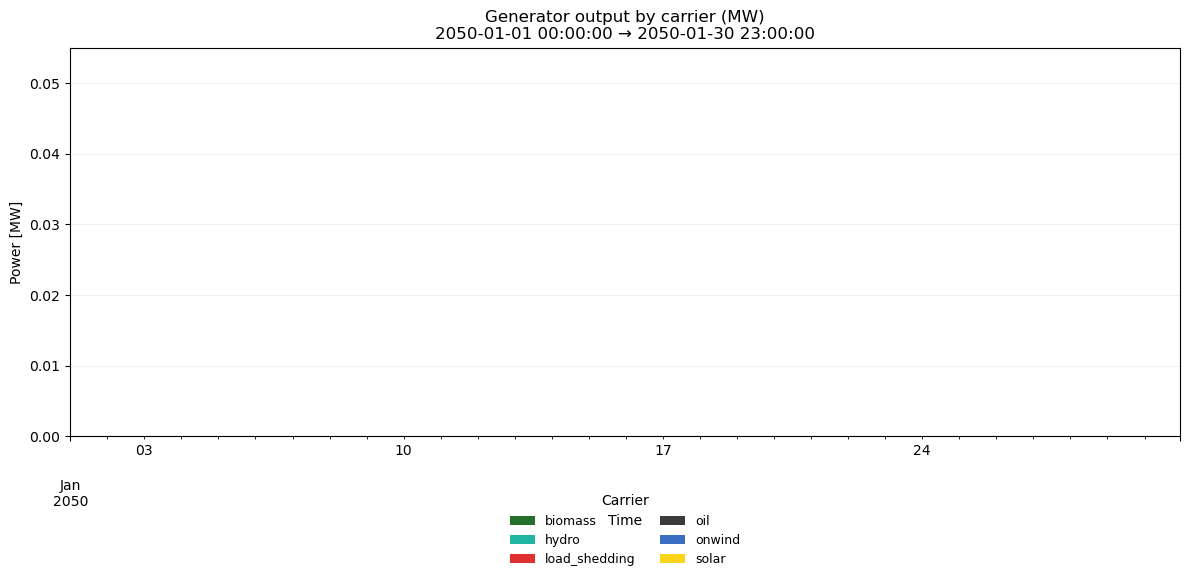

IndexError: list index out of range

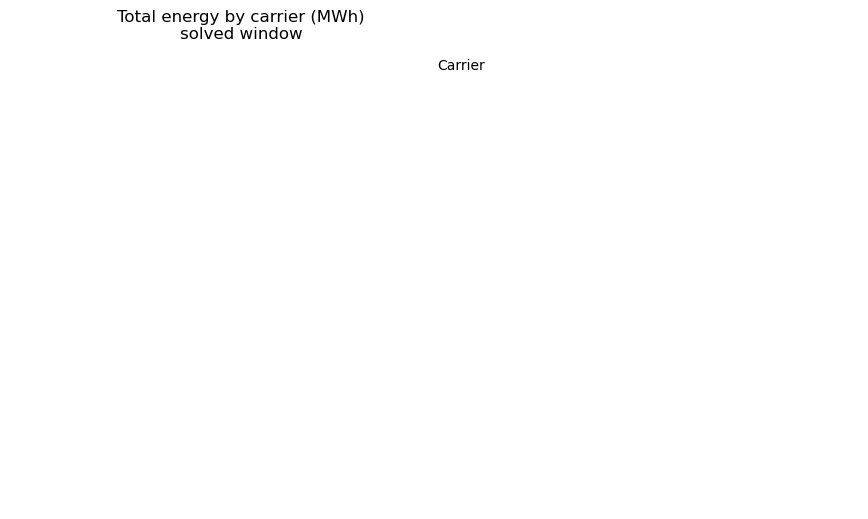

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n = network  # alias

def solved_snapshots(n, prefer=None):
    """Return the snapshots that actually have results."""
    if prefer is not None:
        return pd.Index(prefer)
    p = n.generators_t.p
    return p.index[p.notna().any(axis=1)]

# 1) pick the range to plot
try:
    # if you defined snapshots_subset earlier, use it
    plot_snaps = solved_snapshots(n, prefer=snapshots_subset)
except NameError:
    plot_snaps = solved_snapshots(n)

# 2) slice to existing data only
p = n.generators_t.p.loc[plot_snaps]                 # MW
gen_to_carrier = n.generators["carrier"].astype(str)
gen_to_carrier = gen_to_carrier.reindex(p.columns)   # align

# 3) aggregate by carrier
p_by_carrier = p.groupby(gen_to_carrier, axis=1).sum().sort_index()

# ---- hours weighting for energy ---------------------------------------------
def snapshot_hours(n, idx):
    """
    Return a Series with the duration [h] of each snapshot in idx.
    Uses n.snapshot_weightings if available, otherwise infers from dt.
    """
    sw = getattr(n, "snapshot_weightings", None)
    if sw is not None:
        if hasattr(sw, "columns") and "generators" in sw.columns:
            return sw.loc[idx, "generators"].astype(float)
        if isinstance(sw, pd.Series):
            return sw.loc[idx].astype(float)

    # fallback: infer from datetime index
    if len(idx) >= 2:
        dt = idx.to_series().diff().dt.total_seconds().shift(-1) / 3600.0
        dt.iloc[-1] = dt.iloc[-2] if len(dt) > 1 else 1.0
        return dt

    return pd.Series(1.0, index=idx)

hours = snapshot_hours(n, p_by_carrier.index)
energy_by_carrier = (p_by_carrier.mul(hours, axis=0)).sum(axis=0)

# sort descending for reporting
energy_by_carrier = energy_by_carrier.sort_values(ascending=False)

# ---- optional: colors from carriers table -----------------------------------
carrier_colors = {}
try:
    if hasattr(n, "carriers") and "color" in n.carriers.columns:
        carrier_colors = n.carriers["color"].dropna().astype(str).to_dict()
except Exception:
    pass
cols = [carrier_colors.get(c, None) for c in p_by_carrier.columns]

# =============================================================================
# 4) STACKED AREA: power by carrier over time
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))
p_by_carrier.plot.area(
    ax=ax,
    linewidth=0,
    alpha=0.9,
    color=cols,
)

ax.set_title(
    f"Generator output by carrier (MW)\n"
    f"{plot_snaps[0]} → {plot_snaps[-1]}"
)
ax.set_xlabel("Time")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.2, axis="y")

# legend outside for clarity
ax.legend(
    title="Carrier",
    ncol=2,
    fontsize=9,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
)
fig.tight_layout()
plt.show()

# =============================================================================
# 5) PIE + TABLE: total energy by carrier (MWh) – publication style
# =============================================================================

# --- (a) optionally group very small slices into "other" ---------------------
total_energy = energy_by_carrier.sum()
threshold_fraction = 0.00000000002  # 2% – tweak if you want

small = energy_by_carrier[energy_by_carrier / total_energy < threshold_fraction]
big   = energy_by_carrier[energy_by_carrier / total_energy >= threshold_fraction]

if not small.empty:
    big["other"] = small.sum()

energy_for_plot = big.sort_values(ascending=False)
shares_pct = 100 * energy_for_plot / energy_for_plot.sum()

# colors (recomputed for possibly grouped series)
colors_pie = [carrier_colors.get(c, None) for c in energy_for_plot.index]

# --- (b) figure with two panels: pie + side table ---------------------------
fig, (ax_pie, ax_tab) = plt.subplots(
    1, 2,
    figsize=(11, 6),
    gridspec_kw={"width_ratios": [2.0, 1.3]}
)

# ----- left: clean pie (no text on wedges that can overlap) ------------------
wedges, _ = ax_pie.pie(
    energy_for_plot.values,
    labels=None,             # no labels on wedges → no overlap
    startangle=90,
    colors=colors_pie,
    wedgeprops=dict(linewidth=0.5, edgecolor="white"),
)

ax_pie.set_title("Total energy by carrier (MWh)\nsolved window")

# Use legend to map color → carrier
legend_labels = [
    f"{name}" for name in energy_for_plot.index
]
ax_pie.legend(
    wedges,
    legend_labels,
    title="Carrier",
    loc="upper left",
    bbox_to_anchor=(0.9, 1.0),
    frameon=False,
    fontsize=9,
)

# ----- right: small table with shares ---------------------------------------
ax_tab.axis("off")

table_data = [
    [name, f"{share:.1f} %", f"{val:,.0f}"]
    for name, share, val in zip(
        energy_for_plot.index,
        shares_pct.values,
        energy_for_plot.values,
    )
]

table = ax_tab.table(
    cellText=table_data,
    colLabels=["Carrier", "Share", "Energy [MWh]"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.25)  # a bit taller for readability

fig.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

gen_id = "Villonaco"

# define your restricted snapshot set
snaps = network.snapshots[:LEN_OPT]

# check generator / storage
if gen_id in network.generators.index:
    series = network.generators_t.p.loc[snaps, gen_id]
elif gen_id in network.storage_units.index:
    series = network.storage_units_t.p.loc[snaps, gen_id]
else:
    raise ValueError(f"Generator/storage '{gen_id}' not found in this network.")

# plot
plt.figure(figsize=(14,4))
plt.plot(series.index, series.values, linewidth=1.2)
plt.title(f"Generation profile – {gen_id} (first {LEN_OPT} snapshots)")
plt.xlabel("Time")
plt.ylabel("Power output (MW)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# get p_nom or p_nom_opt
p_nom = network.generators.at[gen_id, "p_nom_opt"] \
        if "p_nom_opt" in network.generators.columns else \
        network.generators.at[gen_id, "p_nom"]

p_max = network.generators_t.p_max_pu.loc[snaps, gen_id] * p_nom

plt.figure(figsize=(14,4))
plt.plot(series, label="Generation", linewidth=1.2)
plt.plot(p_max, label="Available potential", alpha=0.7)
plt.title(f"{gen_id} – Actual vs Available (first {LEN_OPT} snapshots)")
plt.xlabel("Time")
plt.ylabel("MW")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n = network  # alias

def solved_snapshots(n, prefer=None):
    """Return the snapshots that actually have results."""
    if prefer is not None:
        return pd.Index(prefer)
    p = n.generators_t.p
    return p.index[p.notna().any(axis=1)]

# 1) pick the range to plot
try:
    plot_snaps = solved_snapshots(n, prefer=snapshots_subset)
except NameError:
    plot_snaps = solved_snapshots(n)

# 2) slice to existing data only
p = n.generators_t.p.loc[plot_snaps]                 # MW
gen_to_carrier = n.generators["carrier"].astype(str)
gen_to_carrier = gen_to_carrier.reindex(p.columns)   # align

# 3) aggregate by carrier (hourly)
p_by_carrier = p.groupby(gen_to_carrier, axis=1).sum().sort_index()

# ================================
# NEW PART → resample to daily sum
# ================================
# Ensure datetime index
p_by_carrier.index = pd.to_datetime(p_by_carrier.index)

# Daily sums in MWh/day
p_daily = p_by_carrier.resample("D").sum()
# ================================

# colors from carriers table
carrier_colors = {}
try:
    if hasattr(n, "carriers") and "color" in n.carriers.columns:
        carrier_colors = n.carriers["color"].dropna().astype(str).to_dict()
except Exception:
    pass
cols = [carrier_colors.get(c, None) for c in p_by_carrier.columns]

# 4) plot daily time series (stacked area)
plt.figure(figsize=(12,6))
p_daily.plot.area(ax=plt.gca(), linewidth=0, alpha=0.9, color=cols)
plt.title(f"Daily generator output by carrier (MWh/day) — {p_daily.index[0].date()} → {p_daily.index[-1].date()}")
plt.xlabel("Day")
plt.ylabel("Energy [MWh/day]")
plt.legend(title="Carrier", ncol=3, fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# Total available capacity per carrier
p_nom_by_carrier = network.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False)
print("Installed capacity [MW]:")
print(p_nom_by_carrier)

# Compare installed capacity vs peak load
total_load = network.loads_t.p_set.sum(axis=1)
peak_load = total_load.max()
total_gen_cap = p_nom_by_carrier.sum()-p_nom_by_carrier["load_shedding"]

print(f"\nPeak load: {peak_load:.1f} MW")
print(f"Total installed generation capacity: {total_gen_cap:.1f} MW")

if total_gen_cap < peak_load:
    print("⚠️ Installed generation capacity < peak load → insufficient generation possible.")
else:
    print("✅ Installed generation capacity ≥ peak load → generation may be sufficient.")


In [ ]:
# Lines with heavy loading (potential congestion)
loading = abs(network.lines_t.p0 / network.lines.s_nom)
congested_lines = loading.max(axis=0)[loading.max(axis=0) > 0.9]
print(f"⚙️  Congested lines (>{90}% loading): {len(congested_lines)}")
display(congested_lines.sort_values(ascending=False))

# Transformers
if len(network.transformers):
    loading_tr = abs(network.transformers_t.p0 / network.transformers.s_nom)
    congested_tr = loading_tr.max(axis=0)[loading_tr.max(axis=0) > 0.9]
    print(f"⚙️  Congested transformers: {len(congested_tr)}")
    display(congested_tr.sort_values(ascending=False))


In [ ]:
# Identify buses with load_shedding generators
ls_gens = network.generators.query("carrier == 'load_shedding'")
ls_buses = ls_gens["bus"].unique()

# Total load_shedding per bus
load_shedding_by_bus = network.generators_t.p[ls_gens.index].sum()
load_shedding_by_bus = load_shedding_by_bus.groupby(ls_gens.loc[load_shedding_by_bus.index, "bus"]).sum()
load_shedding_by_bus=load_shedding_by_bus[load_shedding_by_bus>0]
load_shedding_by_bus.sort_values(ascending=False).to_csv("load_shedding_buses.csv")
# Print top affected buses
print("Top buses with load shedding:")
print(load_shedding_by_bus.sort_values(ascending=False).head(10).index)



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Build bus_sizes from loads (sum over time), with index dtype aligned ---
# 1) totals per LOAD
load_totals = network.loads_t.p.sum()                  # index: load_id

# 2) map load -> bus, making sure dtype matches network.buses.index
bus_index_dtype = network.buses.index.dtype
load_to_bus = network.loads["bus"].astype(bus_index_dtype)

# 3) aggregate to BUS and reindex to full bus list
bus_sizes = load_totals.groupby(load_to_bus).sum()
bus_sizes = bus_sizes.reindex(network.buses.index).fillna(0)
bus_sizes = bus_sizes*100/max(bus_sizes)
# 4) scale for plotting
bus_sizes = 1e-4* bus_sizes

# (optional) sanity check
# print("bus_sizes dtype:", bus_sizes.index.dtype, "| buses dtype:", network.buses.index.dtype)

# --- Plot ---
network.plot(bus_sizes=bus_sizes, line_widths=1)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Generation aggregated by BUS (dispatched energy over time), log-scaled ---
bus_index_dtype = network.buses.index.dtype

# 1) exclude load_shedding generators
gen_mask = network.generators["carrier"] != "load_shedding"
gens = network.generators.index[gen_mask]

# 2) total dispatched "energy" per generator (sum MW over snapshots -> MWh if 1h)
gen_totals = network.generators_t.p[gens].sum()  # index: generator_id

# 3) map generator -> bus, align dtype
gen_to_bus = network.generators.loc[gens, "bus"].astype(bus_index_dtype)

# 4) aggregate to bus
bus_gen = gen_totals.groupby(gen_to_bus).sum()
bus_gen = bus_gen.reindex(network.buses.index).fillna(0)

# 5) log10 scaling (filter zeros first)
bus_sizes = pd.Series(0.0, index=network.buses.index)
bus_gen_pos = bus_gen[bus_gen > 0]

if len(bus_gen_pos) > 0:
    bus_gen_log = np.log10(bus_gen_pos)

    # Optional: rescale log values to 0..100 for nicer marker sizing
    denom = (bus_gen_log.max() - bus_gen_log.min()) + 1e-12
    bus_sizes.loc[bus_gen_log.index] = (bus_gen_log - bus_gen_log.min()) / denom * 100.0

# 6) scale for plotting (keep your style)
bus_sizes = 1e-4 * bus_sizes

# --- Plot ---
network.plot(bus_sizes=bus_sizes, line_widths=1)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load shedding aggregated by BUS (sum over time), log-scaled ---
bus_index_dtype = network.buses.index.dtype

# 1) keep only load_shedding generators
ls_mask = network.generators["carrier"] == "load_shedding"
ls_gens = network.generators.index[ls_mask]

# 2) total shedding per generator (sum MW over snapshots -> MWh if 1h)
ls_totals = network.generators_t.p[ls_gens].sum()  # index: generator_id

# 3) map shedding gen -> bus, align dtype
ls_to_bus = network.generators.loc[ls_gens, "bus"].astype(bus_index_dtype)

# 4) aggregate to bus
bus_ls = ls_totals.groupby(ls_to_bus).sum()
bus_ls = bus_ls.reindex(network.buses.index).fillna(0)

# 5) log10 scaling (filter zeros first)
bus_sizes = pd.Series(0.0, index=network.buses.index)
bus_ls_pos = bus_ls[bus_ls > 0]

if len(bus_ls_pos) > 0:
    bus_ls_log = np.log10(bus_ls_pos)

    # rescale log values to 0..100 for nicer marker sizing
    denom = (bus_ls_log.max() - bus_ls_log.min()) + 1e-12
    bus_sizes.loc[bus_ls_log.index] = (bus_ls_log - bus_ls_log.min()) / denom * 100.0

# 6) scale for plotting (same style as before)
bus_sizes = 1e-4 * bus_sizes

# --- Plot ---
network.plot(bus_sizes=bus_sizes, line_widths=1)
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# 1) ENS por bus (MWh en todo el año)
ls_gens = n.generators.index[n.generators.carrier == "load_shedding"]
ens_by_gen = n.generators_t.p[ls_gens].sum()  # MWh si p está en MW y snapshots son 1h
ens_by_bus = ens_by_gen.groupby(n.generators.loc[ls_gens, "bus"]).sum().sort_values(ascending=False)

print("Top shedding buses (MWh/año):")
print(ens_by_bus.head(20))

# 2) Horas con shedding (persistencia)
ens_t = n.generators_t.p[ls_gens].sum(axis=1)  # MW por hora
print("Horas con shedding:", (ens_t > 1e-3).sum(), "de", len(ens_t))

# 3) Líneas más congestionadas
# (si usas DC/LPF, p0 suele existir; para AC mira s si lo guardas)
util = (n.lines_t.p0.abs().div(n.lines.s_nom)).max().sort_values(ascending=False)
print("Top líneas por utilización máxima:")
print(util.head(100))

In [ ]:
lines_df = copy.deepcopy(network.lines)
lines_df.drop(columns=['geometry', "bounds"], inplace=True, errors='ignore')
lines_df.to_csv("lines_data.csv")

In [ ]:
if len(n.transformers):
    trafo_limit = n.transformers.s_nom * n.transformers.s_max_pu
    trafo_util = (n.transformers_t.p0.abs().div(trafo_limit)).max().sort_values(ascending=False)
    print(trafo_util.head(20))

In [ ]:
if len(n.links):
    # ojo: links limitan por p_nom (no s_nom)
    link_limit = n.links.p_nom * n.links.p_max_pu
    link_util = (n.links_t.p0.abs().div(link_limit)).max().sort_values(ascending=False)
    print(link_util.head(20))

In [ ]:
ls = n.generators.index[n.generators.carrier == "load_shedding"]
ens_by_bus = n.generators_t.p[ls].sum().groupby(n.generators.bus).sum()

bus_sn = n.buses.sub_network
ens_by_sn = ens_by_bus.groupby(bus_sn).sum().sort_values(ascending=False)
ens_by_sn


In [ ]:
loads_by_bus = n.loads_t.p_set.sum()  # MWh/año si snapshots=1h
load_bus_sn = n.loads.bus.map(n.buses.sub_network)

gen_dispatch = n.generators_t.p.sum()  # MWh/año
gen_by_bus = n.generators_t.p.sum().groupby(n.generators.bus).sum()
gen_by_sn = gen_by_bus.groupby(bus_sn).sum()

load_by_bus = n.loads_t.p_set.sum().groupby(n.loads.bus).sum()
load_by_sn = load_by_bus.groupby(bus_sn).sum()

pd.DataFrame(dict(load_MWh=load_by_sn, gen_MWh=gen_by_sn, ens_MWh=ens_by_sn)).fillna(0).sort_values("ens_MWh", ascending=False)


In [ ]:
network.generators_t.p